In [31]:
import pandas as pd
import seaborn as sns
import sys, os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append('../../scripts/signals_analysis')

from calculate import get_signals
from save import save_signals

## 1. Pair heatmaps for single experiment with DMSO and IAA treatment
(output 2 heatmaps)

In [7]:
output_dir = '../../results/heatmaps/spikein' # where plots are saved

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
DMSO_signals_path = '../../results/signals/spikein_mean/RDY418_as_DMSO_25_nC_spikein.csv'
IAA_signals_path = '../../results/signals/spikein_mean/RDY418_as_IAA_25_nC_spikein.csv'


DMSO_signals = pd.read_csv(DMSO_signals_path, sep='\t', header=None)
IAA_signals = pd.read_csv(IAA_signals_path, sep='\t', header=None)

In [9]:
def plot_pair_peaks(P1, P2):
    ''' Generate heatplots for pair of signals (DMSO and IAA).
    Color scale is the same for given pair, with max(P1,P2) and min(P1,P2).
    '''
    fig = plt.figure(figsize=(6, 12))
    gs = gridspec.GridSpec(2, 2, height_ratios=[1, 4], wspace=0.1, hspace=0.1)

    vmax = max(P1.values.max(), P2.values.max())
    vmin = min(P1.values.min(), P2.values.min())

    meanmax = max(P1.mean(axis=0).max(), P2.mean(axis=0).max()) + 5
    # Set minimum to 0 instead of the actual minimum
    meanmin = 0

    # Top left plot
    ax1 = plt.subplot(gs[0])
    ax1.set_facecolor(color='whitesmoke')
    ax1.grid(False)
    ax1.plot(P1.mean(axis=0), color="blue")
    ax1.set_ylabel('Average signal')
    ax1.set_ylim(meanmin, meanmax)
    ax1.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax1.tick_params(left=True)

    # Bottom left plot (heatmap)
    ax2 = plt.subplot(gs[2])
    sns.heatmap(data=P1, cmap='Spectral_r', ax=ax2,
                vmin=vmin, vmax=vmax,
                #cbar=False, # remove scale bar
                cbar_kws={'aspect': 30, 'location': 'bottom'})
    ax2.set(yticks=[])
    ax2.set_ylabel(f'n={P1.shape[0]}') # add number of peaks used for heatmaps
    ax2.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
    ax2.tick_params(bottom=True)

    # Top right plot
    ax3 = plt.subplot(gs[1])
    ax3.set_facecolor(color='whitesmoke')
    ax3.grid(False)
    ax3.plot(P2.mean(axis=0), color="blue")
    ax3.set_ylim(meanmin, meanmax)
    ax3.set_xlim(0, 151)
    ax3.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax3.set_yticks([])

    # Bottom right plot (heatmap)
    ax4 = plt.subplot(gs[3])
    sns.heatmap(data=P2, cmap='Spectral_r', ax=ax4,
                vmin=vmin, vmax=vmax,
                #cbar=False, #remove scale bar 
                cbar_kws={'aspect': 30, 'location': 'bottom'})
    ax4.set(yticks=[])
    ax4.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
    ax4.tick_params(bottom=True)

    plt.tight_layout()

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_1637/714860667.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


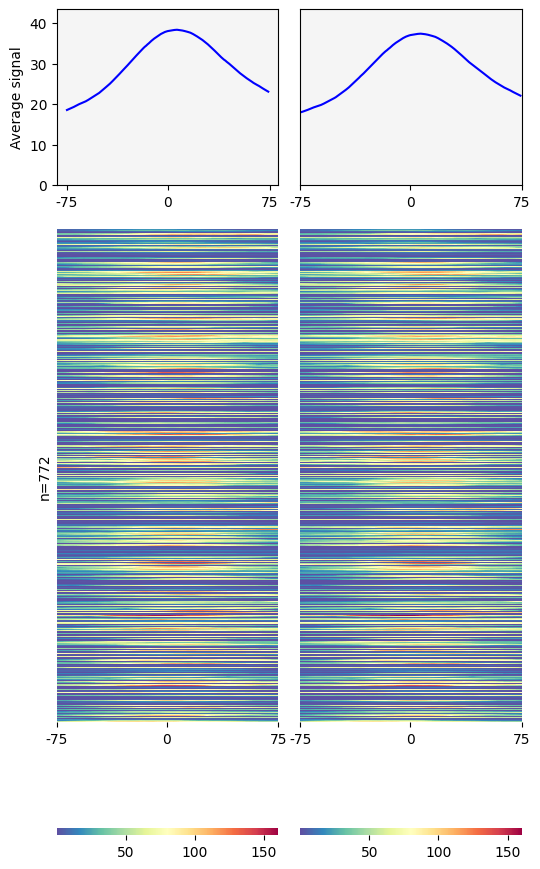

In [10]:
# Plot signals
# Sort both DataFrames in descending order by DMSO
#DMSO_signals = DMSO_signals.T
#IAA_signals = IAA_signals.T
#DMSO_signals = DMSO_signals.loc[DMSO_signals.apply(sum, axis=1).sort_values(ascending=False).index]
#IAA_signals = IAA_signals.loc[DMSO_signals.apply(sum, axis=1).sort_values(ascending=False).index]

plot_pair_peaks(DMSO_signals.T, IAA_signals.T)

# Save figure with meaningful name
name = os.path.basename(DMSO_signals_path).split('.')[0]
name = name + '_vs_' + os.path.basename(IAA_signals_path).split('.')[0]
plt.savefig(f'{output_dir}/{name}.png', dpi=300)

## 2. Four heatmaps for single strain from 4 different phases of cell cycle
Calculates signals from 4 samples (asynchronized, G1, S, G2) from wig files for provided .bed file with coordinates of common peaks and generates heatmaps.

In [59]:
#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
output_dir = '../../results/heatmaps/cpm'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
as_signals = pd.read_csv('../../results/signals/cpm_mean/RDY412_as_nTr_nT_nC_cpm.csv', sep='\t', header=None)
G1_signals = pd.read_csv('../../results/signals/cpm_mean/RDY412_G1_nTr_nT_nC_cpm.csv', sep='\t', header=None)
S_signals = pd.read_csv('../../results/signals/cpm_mean/RDY412_S_nTr_nT_nC_cpm.csv', sep='\t', header=None)
G2_signals = pd.read_csv('../../results/signals/cpm_mean/RDY412_G2_nTr_nT_nC_cpm.csv', sep='\t', header=None)

In [60]:
def plot_peaks_phases(AS, G1, S, G2):
    fig = plt.figure(figsize=(12, 9))
    gs = gridspec.GridSpec(2, 4, height_ratios=[1, 4], hspace=0.1, wspace=0.3)
    
    # To plots be comparable, define vmax/vmin from all datasets
    vmax = max(AS.max().max(), G1.max().max(), S.max().max(), G2.max().max())
    vmin = min(AS.min().min(), G1.min().min(), S.min().min(), G2.min().min())

    # Lists of datasets and their positions
    datasets = [AS, G1, S, G2]
    titles = ['Asynchronised', 'G1', 'S', 'G2']
    
    for i, (data, title) in enumerate(zip(datasets, titles)):
        # Top row plot (average signal)
        ax_top = plt.subplot(gs[0, i])  # Row 0, Column i
        ax_top.set_facecolor('whitesmoke')
        ax_top.grid(False)
        ax_top.plot(data.mean(axis=0), color="blue")
        
        if i == 0:  # Only first plot gets y-label
            ax_top.set_ylabel('Average signal', fontsize=15)
        else:
            ax_top.set_yticks([])
            
        bot = int(data.mean(axis=0).min())
        ax_top.set_ylim(bot, vmax/2.5)
        ax_top.set_xlim(0, 151)
        ax_top.set_xticks([])
        ax_top.set_title(title)
        
        # Bottom row plot (heatmap)
        ax_bottom = plt.subplot(gs[1, i])  # Row 1, Column i
        sns.heatmap(data=data, cmap='Spectral_r', ax=ax_bottom,
                    vmin=vmin, vmax=vmax,
                    #cbar=False # plot without scale colorbar
                    cbar_kws={'aspect': 30, 'location': 'bottom'})
        
        ax_bottom.set(yticks=[])
        ax_bottom.set_ylabel(f'n={data.shape[0]}' if i == 0 else '', fontsize=15)  # Only first plot gets y-label
        
        # X-axis settings for all bottom plots
        ax_bottom.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
        ax_bottom.set_xticklabels(ax_bottom.get_xticklabels(), rotation=0, fontsize=15)

    plt.tight_layout()
    plt.show()

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_1637/3411752372.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


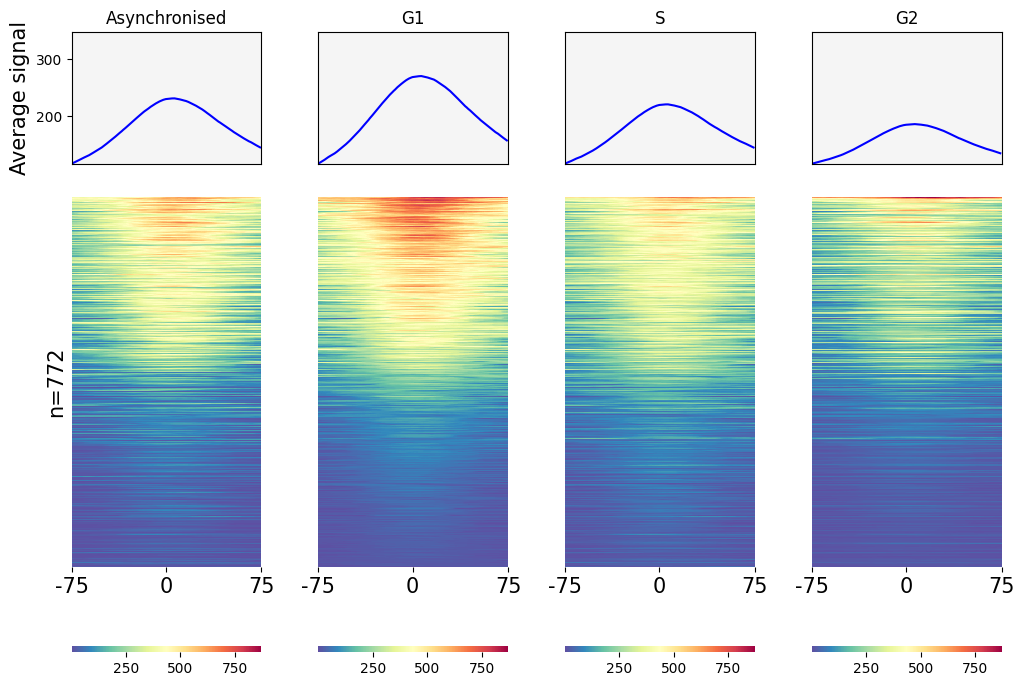

In [61]:
# Plot signals
# Sort both DataFrames in descending order by G1
as_signals = as_signals.T
G1_signals = G1_signals.T
S_signals = S_signals.T
G2_signals = G2_signals.T

G1_signals = G1_signals.loc[G1_signals.apply(sum, axis=1).sort_values(ascending=False).index]
as_signals = as_signals.loc[G1_signals.apply(sum, axis=1).sort_values(ascending=False).index]
S_signals = S_signals.loc[G1_signals.apply(sum, axis=1).sort_values(ascending=False).index]
G2_signals = G2_signals.loc[G1_signals.apply(sum, axis=1).sort_values(ascending=False).index]

plot_peaks_phases(AS=as_signals,
                  G1=G1_signals,
                  S=S_signals,
                  G2=G2_signals)

## 3. Single heatmap

In [38]:
#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
output_dir = '../../results/heatmaps/cpm'

#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
signals = pd.read_csv('../../results/signals/cpm_mean/early_origins/RDY412_G1_nTr_nT_nC_cpm.csv', sep='\t', header=None).T

In [39]:
def plot_single(P1):
    ''' Generate heatmap and average signal plot for a single dataframe.
    '''
    fig = plt.figure(figsize=(4, 12))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 4], hspace=0.1)

    # Calculate vmin and vmax from the single dataframe
    vmax = P1.values.max()
    vmin = P1.values.min()

    # Calculate mean max for y-axis limit
    meanmax = P1.mean(axis=0).max() + 5
    meanmin = 0

    # Top plot - Average signal
    ax1 = plt.subplot(gs[0])
    ax1.set_facecolor(color='whitesmoke')
    ax1.grid(False)
    ax1.plot(P1.mean(axis=0), color="blue")
    ax1.set_ylabel('Average signal', fontsize=15)
    ax1.set_ylim(meanmin, meanmax)
    ax1.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax1.tick_params(left=True)

    # Bottom plot - Heatmap
    ax2 = plt.subplot(gs[1])
    sns.heatmap(data=P1, cmap='Spectral_r', ax=ax2,
                vmin=vmin, vmax=vmax,
                cbar_kws={'aspect': 30, 'location': 'bottom'})
    ax2.set(yticks=[])
    ax2.set_ylabel(f'n={P1.shape[0]}', fontsize=15)  # add number of peaks used for heatmap
    ax2.set(xticks=[0, 75, 151], xticklabels=['-75', '0', '75'])
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0, fontsize=15)
    ax2.tick_params(bottom=True)

    plt.tight_layout()

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_45014/3745368455.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


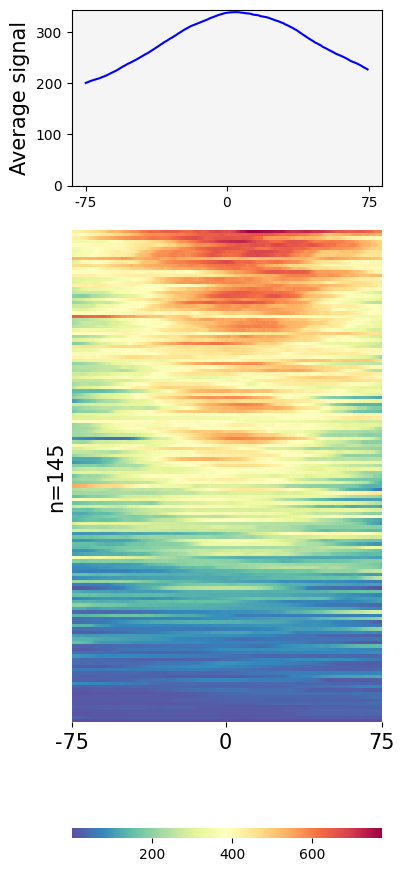

In [40]:
signals = signals.loc[signals.apply(sum, axis=1).sort_values(ascending=False).index]
plot_single(signals)